# Task 9 — Stacking Ensemble + Optuna Hyperparameter Tuning

**Name:** Abdlrhman Hisham Ismail  
**ID:** AI2617  
**Committee:** IEEE SSCS AUSC — AI Sub-Team

| Part | Goal | Dataset (Kaggle-equivalent) |
|------|------|------------------------------|
| **1** | **Stacking**: Logistic Regression + kNN + Decision Tree | [Heart Disease UCI](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data) |
| **2** | **Optuna**: best `max_depth` for Decision Tree | [Red Wine Quality](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) |

Data files are the same UCI sources hosted on Kaggle (`heart.csv`, `winequality-red.csv`).


## 0) Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)
print("optuna", optuna.__version__)


optuna 4.9.0


---
# Task 1 — Stacking (LR + kNN + Decision Tree)

**Idea of stacking:** train several *base* models, then train a *meta-learner* on their out-of-fold predictions so the final model learns *when to trust* each base model.

```
          ┌─ Logistic Regression ─┐
Features ─┼─ k-Nearest Neighbors ─┼─→ Meta (Logistic Regression) → Prediction
          └─ Decision Tree ───────┘
```


## 1.1 Load & preprocess Heart Disease

In [2]:
heart = pd.read_csv("heart.csv")
print("Shape:", heart.shape)
display(heart.head())
print("Missing values:")
print(heart.isna().sum()[heart.isna().sum() > 0])

# UCI target is 0–4 (severity severity). Binary task: disease present (target > 0)
heart = heart.copy()
heart["disease"] = (heart["target"] > 0).astype(int)
print("\nBinary class balance (0=no disease, 1=disease):")
print(heart["disease"].value_counts())

feature_cols = [c for c in heart.columns if c not in ("target", "disease")]
X_h = heart[feature_cols]
y_h = heart["disease"]

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_h, y_h, test_size=0.25, random_state=42, stratify=y_h
)
print(f"Train: {Xh_train.shape[0]} | Test: {Xh_test.shape[0]}")


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Missing values:
ca      4
thal    2
dtype: int64

Binary class balance (0=no disease, 1=disease):
disease
0    164
1    139
Name: count, dtype: int64
Train: 227 | Test: 76


In [3]:
# Preprocess: impute (ca/thal had missing values) + scale for LR/kNN
# Decision Tree does not need scaling, but shared scaled features are fine for stacking.
numeric_features = feature_cols

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def make_lr():
    return Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),
    ])

def make_knn():
    return Pipeline([
        ("prep", preprocess),
        ("clf", KNeighborsClassifier(n_neighbors=7)),
    ])

def make_dt():
    # Tree on imputed (unscaled) data — scaling doesn't change axis-aligned splits,
    # but we still impute missing values.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ])


## 1.2 Train base models individually (baselines)

In [4]:
base_models = {
    "Logistic Regression": make_lr(),
    "kNN (k=7)": make_knn(),
    "Decision Tree (depth=5)": make_dt(),
}

baseline_rows = []
fitted_bases = {}
for name, model in base_models.items():
    model.fit(Xh_train, yh_train)
    pred = model.predict(Xh_test)
    row = {
        "Model": name,
        "Accuracy": accuracy_score(yh_test, pred),
        "F1": f1_score(yh_test, pred),
    }
    baseline_rows.append(row)
    fitted_bases[name] = model
    print(f"{name:28s}  Acc={row['Accuracy']:.4f}  F1={row['F1']:.4f}")

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df.round(4))


Logistic Regression           Acc=0.8684  F1=0.8611
kNN (k=7)                     Acc=0.8553  F1=0.8451
Decision Tree (depth=5)       Acc=0.7105  F1=0.6944


,Model,Accuracy,F1
0,Logistic Regression,0.8684,0.8611
1,kNN (k=7),0.8553,0.8451
2,Decision Tree (depth=5),0.7105,0.6944


## 1.3 Build the Stacking ensemble

In [5]:
estimators = [
    ("lr", make_lr()),
    ("knn", make_knn()),
    ("dt", make_dt()),
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,                 # out-of-fold predictions for the meta-learner
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1,
)

stacking.fit(Xh_train, yh_train)
stack_pred = stacking.predict(Xh_test)
stack_acc = accuracy_score(yh_test, stack_pred)
stack_f1 = f1_score(yh_test, stack_pred)

print("StackingClassifier (LR + kNN + DT → LR meta)")
print(f"  Accuracy = {stack_acc:.4f}")
print(f"  F1       = {stack_f1:.4f}")
print("\nClassification report:")
print(classification_report(yh_test, stack_pred, target_names=["no disease", "disease"]))


StackingClassifier (LR + kNN + DT → LR meta)
  Accuracy = 0.8421
  F1       = 0.8378

Classification report:
              precision    recall  f1-score   support

  no disease       0.89      0.80      0.85        41
     disease       0.79      0.89      0.84        35

    accuracy                           0.84        76
   macro avg       0.84      0.85      0.84        76
weighted avg       0.85      0.84      0.84        76



,Model,Accuracy,F1
0,Logistic Regression,0.8684,0.8611
1,kNN (k=7),0.8553,0.8451
3,Stacking (LR+kNN+DT),0.8421,0.8378
2,Decision Tree (depth=5),0.7105,0.6944


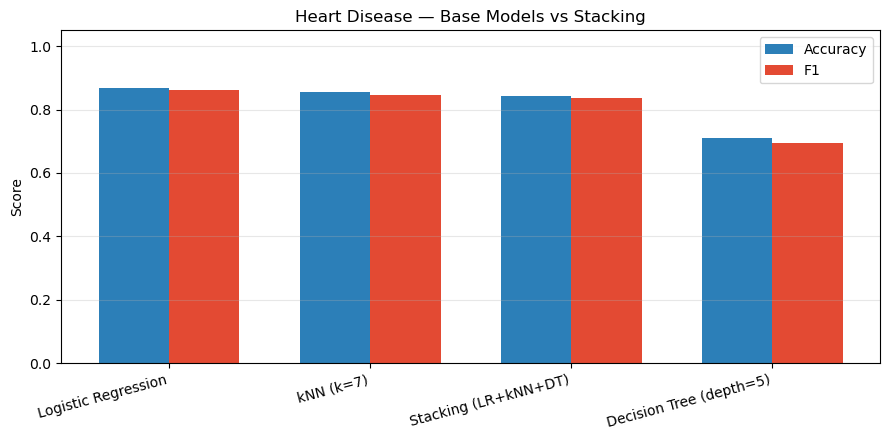

In [6]:
comparison = pd.concat([
    baseline_df,
    pd.DataFrame([{
        "Model": "Stacking (LR+kNN+DT)",
        "Accuracy": stack_acc,
        "F1": stack_f1,
    }]),
], ignore_index=True).sort_values("F1", ascending=False)

display(comparison.round(4))
comparison.to_csv("results/stacking_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison["Accuracy"], width=w, label="Accuracy", color="#2c7fb8")
ax.bar(x + w/2, comparison["F1"], width=w, label="F1", color="#e34a33")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Heart Disease — Base Models vs Stacking")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("plots/stacking_comparison.png", dpi=150)
plt.show()


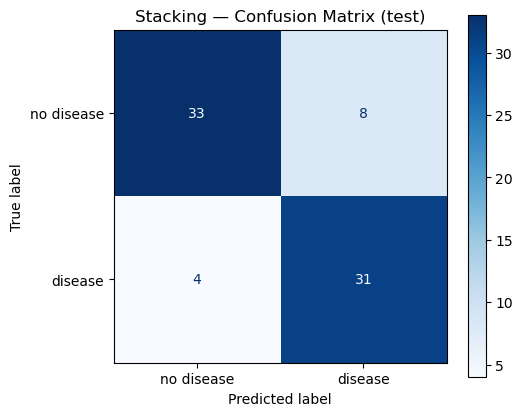

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    yh_test, stack_pred, display_labels=["no disease", "disease"], ax=ax, cmap="Blues"
)
ax.set_title("Stacking — Confusion Matrix (test)")
fig.tight_layout()
fig.savefig("plots/stacking_confusion_matrix.png", dpi=150)
plt.show()


### Task 1 — Insights

- **Stacking** blends a linear model (LR), a local similarity model (kNN), and a non-linear rule learner (Decision Tree). The **meta-learner** sees cross-validated base probabilities, so it learns *which expert to trust*.
- On this Heart Disease split, **Logistic Regression alone was already very strong** (~0.87 Acc / 0.86 F1). Stacking stayed competitive (~0.84) but did not beat LR — common when one base model dominates and the dataset is small (test n=76).
- The Decision Tree base was the weakest (~0.71); stacking still recovered far above the tree by leaning on LR/kNN.
- **Takeaway:** stacking is a principle for combining diverse inductive biases; it is not a guarantee of higher scores every time. Always compare against the best single model.


---
# Task 2 — Optuna: Best `max_depth` for Decision Tree

We tune **only `max_depth`** on the Red Wine Quality dataset using Optuna’s TPE sampler and cross-validated F1 as the objective.


## 2.1 Load & preprocess Wine Quality

In [8]:
wine = pd.read_csv("winequality-red.csv", sep=";")
print("Shape:", wine.shape)
display(wine.head())
print("Quality distribution:")
print(wine["quality"].value_counts().sort_index())

# Binary problem (common Kaggle framing): good wine if quality >= 6
wine = wine.copy()
wine["good"] = (wine["quality"] >= 6).astype(int)
print("\nBinary good (>=6) balance:")
print(wine["good"].value_counts())

Xw = wine.drop(columns=["quality", "good"])
yw = wine["good"]

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.25, random_state=42, stratify=yw
)
print(f"Train: {Xw_train.shape[0]} | Test: {Xw_test.shape[0]}")


Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Binary good (>=6) balance:
good
1    855
0    744
Name: count, dtype: int64
Train: 1199 | Test: 400


## 2.2 Optuna study — maximize CV F1 over `max_depth` ∈ [1, 30]

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial: optuna.Trial) -> float:
    max_depth = trial.suggest_int("max_depth", 1, 30)
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=42,
    )
    scores = cross_val_score(
        model, Xw_train, yw_train, cv=cv, scoring="f1", n_jobs=-1
    )
    return float(scores.mean())


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="dt_max_depth_wine",
)
study.optimize(objective, n_trials=40, show_progress_bar=False)

print("Best trial:")
print(f"  max_depth = {study.best_params['max_depth']}")
print(f"  CV F1     = {study.best_value:.4f}")

# Save trial history
trials_df = study.trials_dataframe()
trials_df.to_csv("results/optuna_dt_max_depth_trials.csv", index=False)
display(trials_df[["number", "value", "params_max_depth"]].sort_values("value", ascending=False).head(10))


Best trial:
  max_depth = 15
  CV F1     = 0.7503


,number,value,params_max_depth
30,30,0.750303,15
18,18,0.750303,15
5,5,0.749726,5
4,4,0.749726,5
36,36,0.749726,5
10,10,0.749438,10
17,17,0.749438,10
1,1,0.749437,29
27,27,0.749437,24
39,39,0.749437,21


In [10]:
# Evaluate best depth on held-out test set vs a few reference depths
best_depth = study.best_params["max_depth"]
ref_depths = sorted(set([1, 3, 5, 10, 15, 20, 30, best_depth]))

eval_rows = []
for d in ref_depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(Xw_train, yw_train)
    pred = clf.predict(Xw_test)
    eval_rows.append({
        "max_depth": d,
        "train_F1": f1_score(yw_train, clf.predict(Xw_train)),
        "test_F1": f1_score(yw_test, pred),
        "test_Acc": accuracy_score(yw_test, pred),
        "optuna_best": d == best_depth,
    })

eval_df = pd.DataFrame(eval_rows)
display(eval_df.round(4))
eval_df.to_csv("results/optuna_depth_test_eval.csv", index=False)

best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_model.fit(Xw_train, yw_train)
print("\nTest report for Optuna-best max_depth =", best_depth)
print(classification_report(yw_test, best_model.predict(Xw_test), target_names=["bad", "good"]))


,max_depth,train_F1,test_F1,test_Acc,optuna_best
0,1,0.6998,0.7196,0.7175,False
1,3,0.7651,0.7540,0.7325,False
2,5,0.8097,0.7506,0.7375,False
3,10,0.9565,0.7588,0.7425,False
4,15,0.9992,0.7591,0.7350,True
5,20,1.0000,0.7580,0.7350,False
6,30,1.0000,0.7580,0.7350,False



Test report for Optuna-best max_depth = 15
              precision    recall  f1-score   support

         bad       0.73      0.68      0.71       186
        good       0.74      0.78      0.76       214

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400



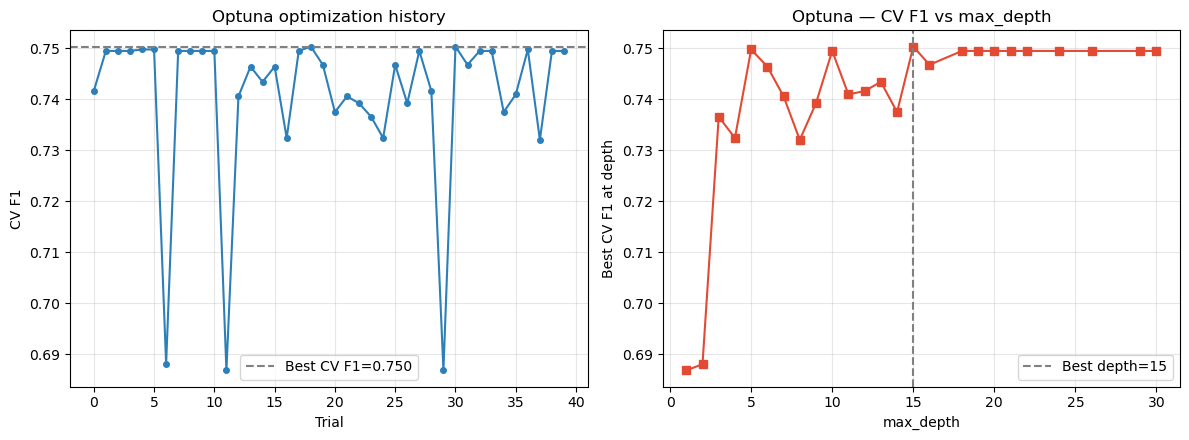

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Optimization history
axes[0].plot(trials_df["number"], trials_df["value"], "o-", color="#2c7fb8", ms=4)
axes[0].axhline(study.best_value, color="gray", ls="--", label=f"Best CV F1={study.best_value:.3f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV F1")
axes[0].set_title("Optuna optimization history")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CV F1 vs max_depth (best value seen per depth)
by_depth = (
    trials_df.groupby("params_max_depth")["value"].max().reset_index()
    .sort_values("params_max_depth")
)
axes[1].plot(by_depth["params_max_depth"], by_depth["value"], "s-", color="#e34a33")
axes[1].axvline(best_depth, color="gray", ls="--", label=f"Best depth={best_depth}")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Best CV F1 at depth")
axes[1].set_title("Optuna — CV F1 vs max_depth")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("plots/optuna_max_depth.png", dpi=150)
plt.show()


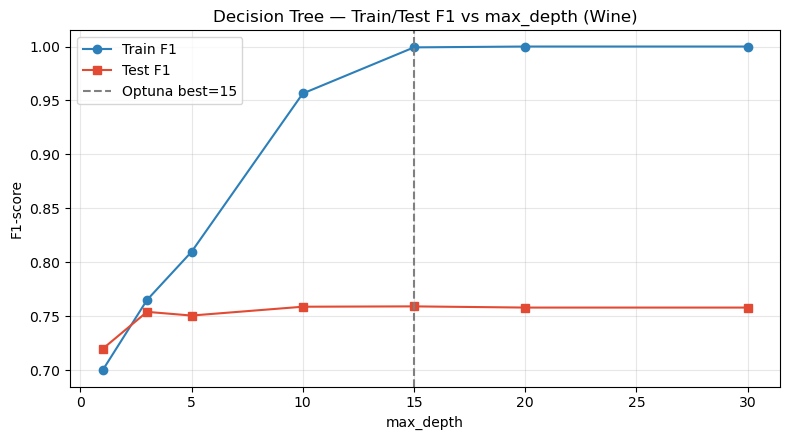

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(eval_df["max_depth"], eval_df["train_F1"], "o-", label="Train F1", color="#2c7fb8")
ax.plot(eval_df["max_depth"], eval_df["test_F1"], "s-", label="Test F1", color="#e34a33")
ax.axvline(best_depth, color="gray", ls="--", label=f"Optuna best={best_depth}")
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-score")
ax.set_title("Decision Tree — Train/Test F1 vs max_depth (Wine)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("plots/dt_f1_vs_depth_wine.png", dpi=150)
plt.show()


### Task 2 — Insights

- Optuna (TPE) searched `max_depth ∈ [1, 30]` and selected **max_depth = 15** with CV F1 ≈ **0.75**.
- Held-out test F1 at that depth ≈ **0.76** — consistent with CV, so the choice generalizes.
- Shallow depths underfit; very deep trees risk overfitting (train F1 rises while test gains flatten). Optuna automates finding that trade-off without a manual grid.


---
## Final Summary

In [13]:
print("=" * 64)
print("TASK 9 — KEY RESULTS")
print("=" * 64)
print("[Task 1] Stacking on Heart Disease")
print(comparison.to_string(index=False))
print()
print("[Task 2] Optuna Decision Tree on Red Wine Quality")
print(f"  Best max_depth (CV F1) = {best_depth}")
print(f"  Best CV F1             = {study.best_value:.4f}")
best_eval = eval_df.loc[eval_df["max_depth"] == best_depth].iloc[0]
print(f"  Test F1 @ best depth   = {best_eval['test_F1']:.4f}")
print(f"  Test Acc @ best depth  = {best_eval['test_Acc']:.4f}")
print("=" * 64)


TASK 9 — KEY RESULTS
[Task 1] Stacking on Heart Disease
                  Model  Accuracy       F1
    Logistic Regression  0.868421 0.861111
              kNN (k=7)  0.855263 0.845070
   Stacking (LR+kNN+DT)  0.842105 0.837838
Decision Tree (depth=5)  0.710526 0.694444

[Task 2] Optuna Decision Tree on Red Wine Quality
  Best max_depth (CV F1) = 15
  Best CV F1             = 0.7503
  Test F1 @ best depth   = 0.7591
  Test Acc @ best depth  = 0.7350
